# Best Candidate Selection

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df_all = root_pandas.read_root('exp7_10_14b_e_all_cut_MVA2_1_applied.root', key='B0')
df_all.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
df_all.eval('p_D_l = D_CMS_p + e_CMS_p', inplace=True)

Welcome to JupyROOT 6.24/06


In [2]:
df_bestSelected=df_all.loc[df_all.groupby(['__experiment__','__run__','__event__','__production__']).B_D_ReChi2.idxmin()]

In [3]:
# Signal components
sig_D_e_nu=df_bestSelected.query('DecayMode=="sig_D_e_nu" and B0_mcErrors<16 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==511').copy()
sig_D_tau_nu=df_bestSelected.query('DecayMode=="sig_D_tau_nu" and B0_mcErrors<32 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==15').copy()
sig_Dst_e_nu=df_bestSelected.query('DecayMode=="sig_Dst_e_nu" and B0_mcErrors<64 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==511').copy()
sig_Dst_tau_nu=df_bestSelected.query('DecayMode=="sig_Dst_tau_nu" and B0_mcErrors<64 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==15').copy()
all_Dstst_e_nu=df_bestSelected.query('DecayMode=="all_Dstst_e_nu" and B0_mcErrors<64 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==511').copy()
all_Dstst_tau_nu=df_bestSelected.query('DecayMode=="all_Dstst_tau_nu" and B0_mcErrors<64 and abs(D_mcPDG)==411 and abs(e_genMotherPDG)==15').copy()

#sig_D_mu_nu=df_bestSelected.query('DecayMode=="sig_D_mu_nu" and B0_mcErrors<16').copy()
#sig_Dst_mu_nu=df_bestSelected.query('DecayMode=="sig_Dst_mu_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
#all_Dstst_mu_nu=df_bestSelected.query('DecayMode=="all_Dstst_mu_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()

# Bkg components
bkg_fakeD = df_bestSelected.query('abs(D_mcPDG)!=411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_combinatorial = df_bestSelected.query('B0_mcPDG==300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_sigOtherBDTaudecay = df_bestSelected.query('(DecayMode=="bkg" or DecayMode=="sig_D_mu_nu" or DecayMode=="sig_Dst_mu_nu" or DecayMode=="all_Dstst_mu_nu") and \
B0_mcPDG!=300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_recoFakeTracksClusters = df_bestSelected.query('B0_mcErrors==512 and B0_isContinuumEvent!=1').copy()
bkg_continuum = df_bestSelected.query('B0_isContinuumEvent==1').copy()

bkg_others = pandas.concat([df_bestSelected,
                           sig_D_e_nu,
                           sig_D_tau_nu,
                           sig_Dst_e_nu,
                           sig_Dst_tau_nu,
                           all_Dstst_e_nu,
                           all_Dstst_tau_nu,
                           bkg_fakeD,
                           bkg_combinatorial,
                           bkg_sigOtherBDTaudecay,
                           bkg_recoFakeTracksClusters,
                           bkg_continuum]).drop_duplicates(keep=False)
# Weird! the bkg_others contains some events with
# correct sig decay hash chain and correct B0_mcPDG, D_mcPDG, e_genMotherPDG,
# but with 128< B0_mcErrors < 256 (misID)

# Plot before fitting

In [9]:
def statistics(df):
    counts=df.count()
    mean=df.mean()
    std=df.std()
    return f'''counts = %d \nmean = %5.3f \nstd = %5.3f''' %(counts,mean,std)

kwarg={'bins':50, 'histtype':'step','lw':2}

    
def plot_components(cut,variable):
    (counts1, bins1) = np.histogram(sig_D_tau_nu.query(cut)[variable], bins=50)
    (counts2, bins2) = np.histogram(sig_Dst_tau_nu.query(cut)[variable], bins=50)
    factor = 50
    plt.hist(bins1[:-1], bins1, weights=factor*counts1,label=f'D_tau_nu \n{statistics(sig_D_tau_nu.query(cut)[variable])}',alpha=0.6)
    sig_D_e_nu.query(cut)[variable].hist(label=f'D_e_nu \n{statistics(sig_D_e_nu.query(cut)[variable])}',**kwarg)
    
    plt.hist(bins2[:-1], bins2, weights=factor*counts2,label=f'Dst_tau_nu \n{statistics(sig_Dst_tau_nu.query(cut)[variable])}',alpha=0.6,histtype='step',lw=2)
    sig_Dst_e_nu.query(cut)[variable].hist(label=f'Dst_e_nu \n{statistics(sig_Dst_e_nu.query(cut)[variable])}',**kwarg)
    all_Dstst_tau_nu.query(cut)[variable].hist(label=f'all_Dstst_tau_nu \n{statistics(all_Dstst_tau_nu.query(cut)[variable])}',**kwarg)
    all_Dstst_e_nu.query(cut)[variable].hist(label=f'all_Dstst_e_nu \n{statistics(all_Dstst_e_nu.query(cut)[variable])}',**kwarg)
    bkg_fakeD.query(cut)[variable].hist(label=f'bkg_fakeD \n{statistics(bkg_fakeD.query(cut)[variable])}',**kwarg)
    bkg_combinatorial.query(cut)[variable].hist(label=f'bkg_combinatorial \n{statistics(bkg_combinatorial.query(cut)[variable])}',**kwarg)
    bkg_sigOtherBDTaudecay.query(cut)[variable].hist(label=f'bkg_sigOtherBDTaudecay \n{statistics(bkg_sigOtherBDTaudecay.query(cut)[variable])}',**kwarg)
    bkg_recoFakeTracksClusters.query(cut)[variable].hist(label=f'bkg_recoFakeTracksClusters \n{statistics(bkg_recoFakeTracksClusters.query(cut)[variable])}',**kwarg)
    bkg_continuum.query(cut)[variable].hist(label=f'bkg_continuum \n{statistics(bkg_continuum.query(cut)[variable])}',**kwarg)
    bkg_others.query(cut)[variable].hist(label=f'bkg_others \n{statistics(bkg_others.query(cut)[variable])}',**kwarg)
    plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)

plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)

len(bkg_fakeD)+len(sig_D_e_nu)+len(sig_D_tau_nu)+len(sig_Dst_e_nu)+len(sig_Dst_tau_nu)+len(all_Dstst_e_nu)+len(all_Dstst_tau_nu)+len(bkg_combinatorial)+len(bkg_sigOtherBDTaudecay)+len(bkg_others)+len(bkg_recoFakeTracksClusters)+len(bkg_continuum)==len(df_bestSelected)

True

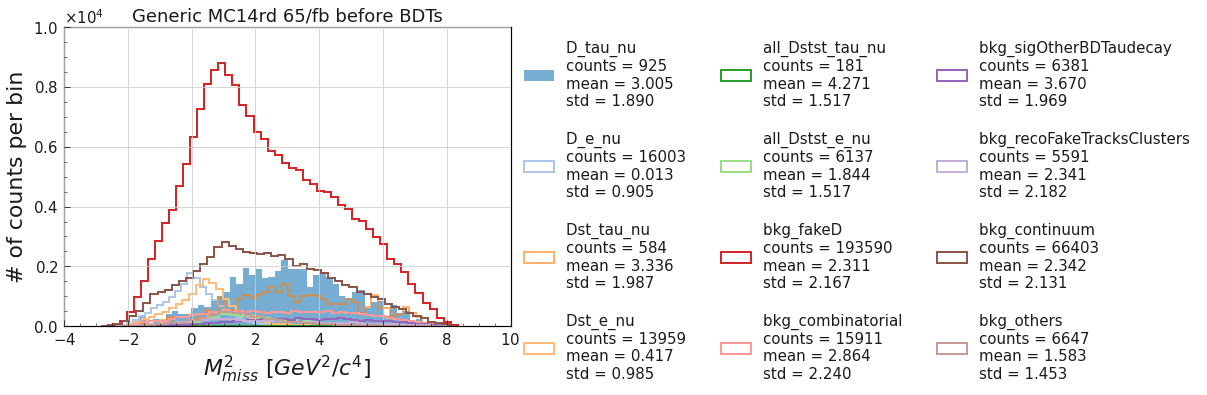

In [6]:
plot_components('MVA1_output>0', 'B0_CMS2_weMissM2')
plt.xlabel("$M_{miss}^2\ [GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('Generic MC14rd 65/fb before BDTs');
#plt.xlim(-10,10)

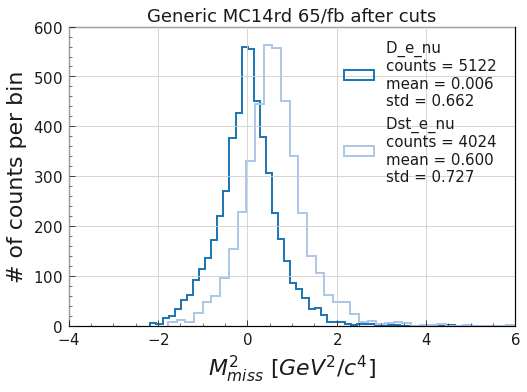

In [11]:
plot_components('MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26', 'B0_CMS2_weMissM2')
plt.xlabel("$M_{miss}^2\ [GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('Generic MC14rd 65/fb after BDTs');
#plt.xlim(-10,10)

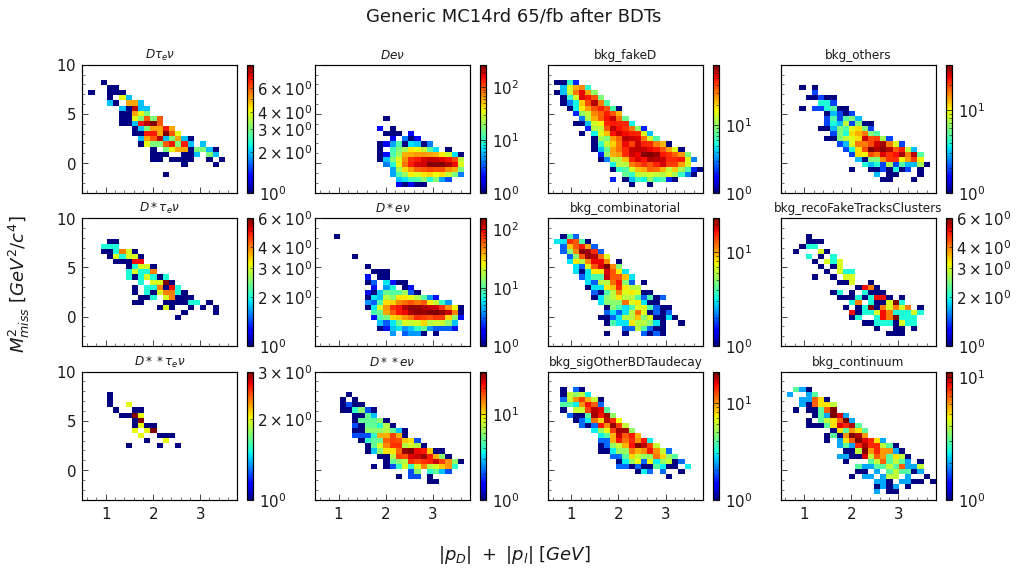

In [8]:
name_list = [r'$D\tau_e\nu$',r'$D*\tau_e\nu$',r'$D**\tau_e\nu$',
             r'$De\nu$',r'$D*e\nu$',r'$D**e\nu$',
             'bkg_fakeD','bkg_combinatorial',
             'bkg_sigOtherBDTaudecay','bkg_others',
             'bkg_recoFakeTracksClusters','bkg_continuum']
df_list = [sig_D_tau_nu,sig_Dst_tau_nu,all_Dstst_tau_nu, 
           sig_D_e_nu,sig_Dst_e_nu,all_Dstst_e_nu, 
           bkg_fakeD,bkg_combinatorial,bkg_sigOtherBDTaudecay,
           bkg_others,bkg_recoFakeTracksClusters, bkg_continuum]   
    
    
df_dict = dict(zip(name_list, df_list))

cuts='MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26'

variable_y = 'B0_CMS2_weMissM2'
variable_x = 'p_D_l'

n_rows,n_cols = [3,4]
fig,ax=plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16,8),sharex=True, sharey='all')
fig.suptitle('Generic MC14rd 65/fb after BDTs')
fig.supxlabel('$|p_D|\ +\ |p_l|\ [GeV]$')
fig.supylabel('$M_{miss}^2\ [GeV^2/c^4]$',x=0.06)
k=0
for j in range(n_cols):
    for i in range(n_rows):
        counts, xedges, yedges, im = ax[i,j].hist2d(df_dict[name_list[k]].query(cuts)[variable_x],
                                                    df_dict[name_list[k]].query(cuts)[variable_y],
                                                    range=[[0.5,3.8],[-3,10]],bins=25,cmap='jet',
                                                    norm=colors.LogNorm())
        ax[i,j].set_title(name_list[k],fontsize=12)
        fig.colorbar(im,ax=ax[i,j])
        k+=1

#plt.xlabel('$p_{D}+p_{l}\ [GeV/c]$')
#plt.ylabel('$M_{miss}^2\ [GeV^2/c^4]$')

# Fitting

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pyhf
pyhf.set_backend('numpy','minuit')

### These two are needed only if to update the templates

bkg_sample = bkg_continuum

cut='B0_roeMbc_my_mask>5.26 and MVA1_output>0.4 and MVA2_1_output>0.2'
xedges = np.linspace(0.5, 4, 15)
yedges = np.linspace(-4, 10, 25)
variable_x = 'p_D_l'
variable_y = 'B0_CMS2_weMissM2'

(counts, xedges, yedges) = np.histogram2d(bkg_sample.query(cut)[variable_x], 
                                          bkg_sample.query(cut)[variable_y],
                                          bins=[xedges, yedges])
counts = counts.T + 0.01

import json

workspace_file = '/home/belle/zhangboy/R_D/Signal_MC_ROEx1/2d_2channels_workspace.json'
with open(workspace_file, 'r+') as f:
    data = json.load(f)
    # data['channels'][0]['samples'].append({}) # no need after the first time
    data['channels'][0]['samples'][11]['name'] = 'bkg_continuum'
    data['channels'][0]['samples'][11]['data'] = counts.ravel().tolist()
    # counts.ravel()/.reshape(-1) returns a view, counts.flatten() returns a copy (slower)
    f.seek(0)        # <--- should reset file position to the beginning.
    json.dump(data, f, indent=4)
    f.truncate()     # remove remaining part
#data['channels'][0]['samples'][5]

In [6]:
cut='B0_roeMbc_my_mask>5.26 and MVA1_output>0.4 and MVA2_1_output>0.2'
electron_mode_samples = df_bestSelected.query(cut)
len(electron_mode_samples)

19444

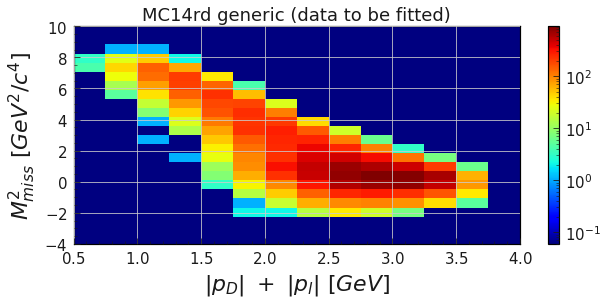

In [7]:
sig_sample = electron_mode_samples

cut='B0_roeMbc_my_mask>5.26 and MVA1_output>0.4 and MVA2_1_output>0.2'
xedges = np.linspace(0.5, 4, 15)
yedges = np.linspace(-4, 10, 25)
variable_x = 'p_D_l'
variable_y = 'B0_CMS2_weMissM2'

(counts, xedges, yedges) = np.histogram2d(sig_sample.query(cut)[variable_x], 
                                          sig_sample.query(cut)[variable_y],
                                          bins=[xedges, yedges])
counts = counts.T + 0.06
fig,axs=plt.subplots(ncols=1,figsize=(10,4))
X, Y = np.meshgrid(xedges, yedges)
im=axs.pcolormesh(X, Y, counts, cmap='jet', norm=colors.LogNorm())
axs.set_title('MC14rd generic (data to be fitted)')
axs.set_ylabel('$M_{miss}^2\ [GeV^2/c^4]$')
axs.set_xlabel('$|p_D|\ +\ |p_l|\ [GeV]$')
#axs.set_aspect('equal')
axs.grid()
fig.colorbar(im)

In [8]:
import json

workspace_file = '/home/belle/zhangboy/R_D/Signal_MC_ROEx1/2d_2channels_workspace.json'
with open(workspace_file, 'r+') as work_f:
    spec = json.load(work_f)
#    spec['observations'][0]['name'] = 'electron mode'
#    spec['observations'][0]['data'] = counts.ravel().tolist()
    spec_1 = {'channels': spec['channels']}
    model_1 = pyhf.Model(spec_1, poi_name=None)
#model_1.spec
#workspace = pyhf.Workspace(spec)
#workspace

In [9]:
import ipywidgets as widgets

sliders_norm = {
    f"n{i}" : widgets.FloatSlider(
        1.0,
        min=0.01,
        max=10.0,
        orientation="vertical",
        continuous_update=False,
        description=f"n{i}",
        layout=widgets.Layout(width='45px')
    )
    for i in range(0, 12)
}

def plot(**kwargs):
    parameters = model_1.config.suggested_init()
    
    for k in kwargs:
        i = int(k.replace("n", ""))
        parameters[i] = kwargs[k]
        
    fig, axs = plt.subplots(ncols=2,figsize=(14,4))
    X, Y = np.meshgrid(xedges, yedges)
    im0=axs[0].pcolormesh(X, Y,
                          model_1.expected_data(parameters).reshape(counts.shape),
                          cmap='jet', norm=colors.LogNorm())
    im1=axs[1].pcolormesh(X, Y, counts, cmap='jet', norm=colors.LogNorm())

    #axs[0].set_aspect('equal')
    #axs[1].set_aspect('equal')
    axs[0].set_title('template')
    axs[1].set_title('data')
    axs[0].grid()
    axs[1].grid()
    fig.colorbar(im0, ax=axs[0])
    fig.colorbar(im1, ax=axs[1])

    print(
        "Negative Log-Likelihood: "
        f"{- model_1.logpdf(parameters, np.concatenate([counts.flat]))[0]:.3f}"
    )
    
interactive_plot = widgets.interactive_output(plot, dict(sliders_norm))
interactive_plot.layout.height = "300px"

def fit(b):
    global parameters, correlations
    parameters, correlations= pyhf.infer.mle.fit(np.concatenate([counts.flat]), model_1, return_uncertainties=True, return_correlations=True)
    sum_event=0
    for k in sliders_norm:
        i = int(k.replace("n", ""))
        sliders_norm[k].value = parameters[i,0]
        template_counts = np.sum(model_1.spec['channels'][0]['samples'][i]['data'])
        component_name = model_1.spec['channels'][0]['samples'][i]['name']
        print(f'\n{component_name} counts:             {parameters[i,0] * template_counts}')
        print(f'{component_name} counts uncertainty: {parameters[i,1] * template_counts}')
        sum_event+= parameters[i,0] * template_counts
    print(f'\nTotal fitted counts: {sum_event}')
    print(f'Total fitted counts uncertainty: ')
    print(f'Total generated counts: {len(electron_mode_samples)}')
    print(f'\nFitting parameters: {parameters}')
    print(f'Fitting parameter correlations: {correlations}')
#    print(f'uncertainty: {parameters[0][1]}')
        
button = widgets.Button(description="Fit")
button.on_click(fit)

display(
    button,
    interactive_plot,
    widgets.HBox(
        [widgets.HBox(layout=widgets.Layout(width='45px'))]
        + [sliders_norm[f"n{i}"] for i in range(0, 12)]
    ),
)

Button(description='Fit', style=ButtonStyle())

Output(layout=Layout(height='300px'))


D_tau_nu counts:             500.38867686851944
D_tau_nu counts uncertainty: 278.0484824806092

D_l_nu counts:             5139.3736238208285
D_l_nu counts uncertainty: 151.31661528686845

Dst_tau_nu counts:             2.4207898858446057e-09
Dst_tau_nu counts uncertainty: 84.48114764968103

Dst_l_nu counts:             3096.0981049649577
Dst_l_nu counts uncertainty: 201.65192239013342

Dstst_tau_nu counts:             8.041848003487171e-13
Dstst_tau_nu counts uncertainty: 41.42852970178246

Dstst_l_nu counts:             4.216829088319294e-09
Dstst_l_nu counts uncertainty: 72.38898162894212

bkg_fakeD counts:             7104.114826454574
bkg_fakeD counts uncertainty: 521.9673572019824

bkg_combinatorial counts:             764.192698609756
bkg_combinatorial counts uncertainty: 186.9550507178503

bkg_sigOtherBDTaudecay counts:             521.2097832453505
bkg_sigOtherBDTaudecay counts uncertainty: 236.18774639167816

bkg_recoFakeTracksClusters counts:             3.4038926760446503e

In [11]:
parameters

array([[1.64582048e-01, 9.14524867e-02],
       [2.09312428e+00, 6.16270589e-02],
       [5.14667464e-12, 1.79609549e-01],
       [7.34786905e+00, 4.78573957e-01],
       [7.28692280e-15, 3.75394434e-01],
       [4.00230551e-11, 6.87063227e-01],
       [1.01424182e+00, 7.45203498e-02],
       [5.51620300e-01, 1.34950519e-01],
       [3.92370881e-01, 1.77804019e-01],
       [1.27792937e-09, 7.94541707e-01],
       [5.90852317e-01, 2.73130087e-01],
       [1.25599813e+00, 1.24380614e-01]])

In [12]:
parameters[2,0]

5.146674644622429e-12

# Plot the fitting results

In [15]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

## Define the slices of projection

In [10]:
from matplotlib import gridspec
import mplhep as hep

print(counts.shape)
p_D_l_slice = 2.5
mm2_slice = 2.4
p_D_l_slice_index, = np.asarray(xedges==p_D_l_slice).nonzero()
mm2_slice_index, = np.asarray(np.isclose(yedges,mm2_slice,atol=0.1)).nonzero()
print([mm2_slice_index[0], p_D_l_slice_index[0]])

(24, 14)
[11, 8]


## Plot with mplhep or plt.bar()

In [37]:
# plotting version: residual = data - all_temp
def plot_projection_residual(direction='MM2', slices=False, plot_with='mplhep'):
    fitted_templates = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,0] for i in range(12)]
    fitted_templates_err = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,1] for i in range(12)]
    fitted_components_names = [model_1.spec['channels'][0]['samples'][i]['name'] for i in range(12)]
    
    def extend(x):
        return np.append(x, x[-1])
    
    def errorband(bins, template_sum, template_err, ax):
        fitted_sum = np.sum(template_sum, axis=0)
        fitted_err = np.sqrt(np.sum(np.array(template_err)**2, axis=0)) # assuming the correlations between each template are 0
        ax.fill_between(bins, extend(fitted_sum - fitted_err), extend(fitted_sum + fitted_err),
        step="post", color="black", alpha=0.3, linewidth=0, zorder=100,)
        
    def plot_with_hep(bins, templates_project, templates_project_err, data, ax1, ax2):
        data_project = data.sum(axis=axis_to_be_summed_over)
        # plot the templates and data
        hep.histplot(templates_project, bin_edges, stack=True, histtype='fill', sort='yield_r', label=fitted_components_names, ax=ax1)
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        hep.histplot(data_project, bin_edges, histtype='errorbar', color='black', w2=data_project, ax=ax1)
        # plot the residual
        residual = data_project - np.sum(templates_project, axis=0)
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        hep.histplot(residual, bin_edges, histtype='errorbar', color='black', yerr=residual_err, ax=ax2)
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Residual',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)
        
    def plot_with_bar(bins, templates_project, templates_project_err, data, ax1, ax2):        
        # calculate the arguments for plotting
        bin_width = bins[1]-bins[0]
        bin_centers = (bins[:-1] + bins[1:]) /2
        data_project = data.sum(axis=axis_to_be_summed_over)
        data_err = np.sqrt(data_project)
        
        # plot the templates
        # sort the components to plot in order of fitted templates_project size
        sorted_indices = sorted(range(12), key=lambda i: np.sum(templates_project[i]), reverse = True)
        bottom_hist = np.zeros(data.shape[1-axis_to_be_summed_over])
        for i in sorted_indices:
            binned_counts = templates_project[i]
            ax1.bar(x=bins[:-1], height=binned_counts, bottom=bottom_hist,
                    width=bin_width, align='edge', label=f"{fitted_components_names[i]}")
            bottom_hist = bottom_hist + binned_counts
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        
        # plot the data
        ax1.errorbar(x=bin_centers, y=data_project, yerr=data_err, fmt='ko')
        # plot the residual
        residual = data_project - np.sum(templates_project, axis=0)
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        ax2.errorbar(x=bin_centers, y=residual, yerr=residual_err, fmt='ko')
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Residual',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)        
    
    if direction=='MM2':
        direction_label = '$M_{miss}^2$'
        direction_unit = '$[GeV^2/c^4]$'
        other_direction_label = '$|p_D|\ +\ |p_l|$'
        other_direction_unit = '[GeV]'
        slice_position = p_D_l_slice
        axis_to_be_summed_over = 1
        bin_edges = yedges
        first_slice_index = (p_D_l_slice_index[0]-1)
        second_slice_index = (p_D_l_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:,:first_slice_index]
        data_slice2 = counts[:,second_slice_index:]
        
    elif direction=='p_D_l':
        direction_label = '$|p_D|\ +\ |p_l|$'
        direction_unit = '[GeV]'
        other_direction_label = '$M_{miss}^2$'
        other_direction_unit = '$[GeV^2/c^4]$'
        slice_position = mm2_slice
        axis_to_be_summed_over = 0
        bin_edges = xedges
        first_slice_index = (mm2_slice_index[0]-1)
        second_slice_index = (mm2_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:first_slice_index,:]
        data_slice2 = counts[second_slice_index:,:]
        
    else:
        raise ValueError('Current version only supports projection to either MM2 or p_D_l')
    
    if not slices:
        fig = plt.figure(figsize=(6.4,6.4))
        gs = gridspec.GridSpec(2,1, height_ratios=[0.8,0.2])
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        #gs.update(hspace=0) 
        fitted_project = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_err = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        
        # plot the templates and data and templates_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project, fitted_project_err, counts, ax1, ax2)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project, fitted_project_err, counts, ax1, ax2)
        ax1.set_title(f'Fitting projection to {direction_label}')
        ax2.set_xlabel(direction_label)
    
    elif slices:
        fig = plt.figure(figsize=(16,7))
        spec = gridspec.GridSpec(5,2, figure=fig, wspace=1, hspace=0.5)
        ax1 = fig.add_subplot(spec[:-1, 0])
        ax2 = fig.add_subplot(spec[:-1, 1])
        ax3 = fig.add_subplot(spec[-1, 0])
        ax4 = fig.add_subplot(spec[-1, 1])
        #gs.update(hspace=0) 
        
        # plot the templates and data and template_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, ax1, ax3)
            plot_with_hep(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, ax2, ax4)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, ax1, ax3)
            plot_with_bar(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, ax2, ax4)
            
        ax1.set_title(f'{other_direction_label} < {slice_position}  {other_direction_unit}')
        ax2.set_title(f'{other_direction_label} > {slice_position}  {other_direction_unit}')
        fig.suptitle(f'Fitted projection to {direction_label} in slices of {other_direction_label}')
        fig.supxlabel(direction_label + '  ' + direction_unit)

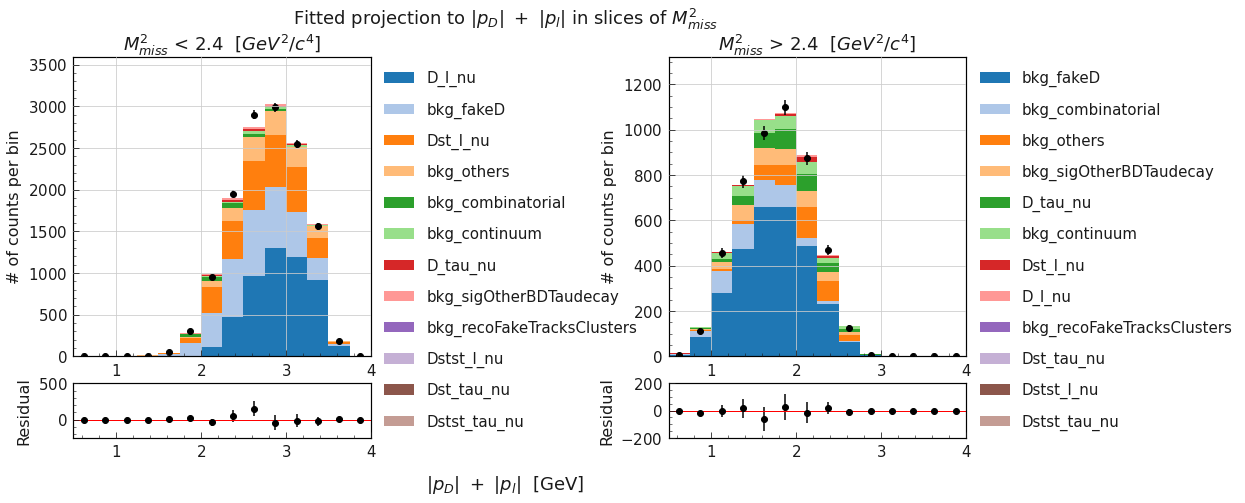

In [38]:
plot_projection_residual(direction='p_D_l',slices=True, plot_with='pltbar')

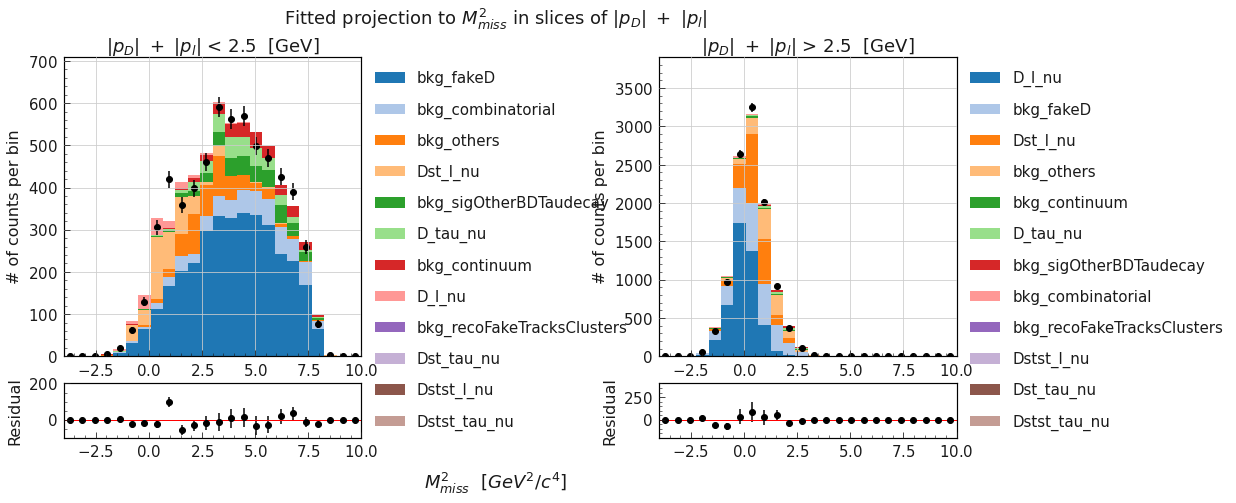

In [39]:
plot_projection_residual(direction='MM2',slices=True, plot_with='pltbar')

In [14]:
# plotting version: two residual plots, residual_signal = data - all_temp + signal1
def plot_projection_residual(direction='MM2', slices=False, plot_with='mplhep'):
    fitted_templates = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,0] for i in range(12)]
    fitted_templates_err = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,1] for i in range(12)]
    fitted_components_names = [model_1.spec['channels'][0]['samples'][i]['name'] for i in range(12)]
    
    def extend(x):
        return np.append(x, x[-1])
    
    def errorband(bins, template_sum, template_err, ax):
        fitted_sum = np.sum(template_sum, axis=0)
        fitted_err = np.sqrt(np.sum(np.array(template_err)**2, axis=0)) # assuming the correlations between each template are 0
        ax.fill_between(bins, extend(fitted_sum - fitted_err), extend(fitted_sum + fitted_err),
        step="post", color="black", alpha=0.3, linewidth=0, zorder=100,)
        
    def plot_with_hep(bins, templates_project, templates_project_err, data, signal_name, ax1, ax2, ax3):
        data_project = data.sum(axis=axis_to_be_summed_over)
        # plot the templates and data
        hep.histplot(templates_project, bin_edges, stack=True, histtype='fill', sort='yield_r', label=fitted_components_names, ax=ax1)
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        hep.histplot(data_project, bin_edges, histtype='errorbar', color='black', w2=data_project, ax=ax1)
        # plot the residual
        signal_index = fitted_components_names.index(signal_name)
        residual = data_project - np.sum(templates_project, axis=0)
        residual_signal = residual + templates_project[signal_index]
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        residual_err_signal = np.sqrt(residual_err**2 - np.array(templates_project_err[signal_index]))
        hep.histplot(residual, bin_edges, histtype='errorbar', color='black', yerr=residual_err, ax=ax2)
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        hep.histplot(residual_signal, bin_edges, histtype='errorbar', color='black', yerr=residual_err_signal, ax=ax3)
        ax3.axhline(y=0, linestyle='-', linewidth=1, color='r')
        
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Residual',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax3.set_ylabel('Data-Bkg',fontsize=16)
        ax3.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)
        
    def plot_with_bar(bins, templates_project, templates_project_err, data, signal_name, ax1, ax2, ax3):        
        # calculate the arguments for plotting
        bin_width = bins[1]-bins[0]
        bin_centers = (bins[:-1] + bins[1:]) /2
        data_project = data.sum(axis=axis_to_be_summed_over)
        data_err = np.sqrt(data_project)
        
        # plot the templates
        # sort the components to plot in order of fitted templates_project size
        sorted_indices = sorted(range(12), key=lambda i: np.sum(templates_project[i]), reverse = True)
        bottom_hist = np.zeros(data.shape[1-axis_to_be_summed_over])
        for i in sorted_indices:
            binned_counts = templates_project[i]
            ax1.bar(x=bins[:-1], height=binned_counts, bottom=bottom_hist,
                    width=bin_width, align='edge', label=f"{fitted_components_names[i]}")
            bottom_hist = bottom_hist + binned_counts
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        
        # plot the data
        ax1.errorbar(x=bin_centers, y=data_project, yerr=data_err, fmt='ko')
        # plot the residual
        signal_index = fitted_components_names.index(signal_name)
        residual = data_project - np.sum(templates_project, axis=0)
        residual_signal = residual + templates_project[signal_index]
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        residual_err_signal = np.sqrt(residual_err**2 - np.array(templates_project_err[signal_index]))
        ax2.errorbar(x=bin_centers, y=residual, yerr=residual_err, fmt='ko')
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        ax3.errorbar(x=bin_centers, y=residual_signal, yerr=residual_err_signal, fmt='ko')
        ax3.axhline(y=0, linestyle='-', linewidth=1, color='r')
                
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Residual',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax3.set_ylabel('Data-Bkg',fontsize=16)
        ax3.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)       
    
    if direction=='MM2':
        direction_label = '$M_{miss}^2$'
        direction_unit = '$[GeV^2/c^4]$'
        other_direction_label = '$|p_D|\ +\ |p_l|$'
        other_direction_unit = '[GeV]'
        slice1_signal = 'D_tau_nu'
        slice2_signal = 'D_l_nu'
        slice_position = p_D_l_slice
        axis_to_be_summed_over = 1
        bin_edges = yedges
        first_slice_index = (p_D_l_slice_index[0]-1)
        second_slice_index = (p_D_l_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:,:first_slice_index]
        data_slice2 = counts[:,second_slice_index:]
        
    elif direction=='p_D_l':
        direction_label = '$|p_D|\ +\ |p_l|$'
        direction_unit = '[GeV]'
        other_direction_label = '$M_{miss}^2$'
        other_direction_unit = '$[GeV^2/c^4]$'
        slice1_signal = 'D_l_nu'
        slice2_signal = 'D_tau_nu'
        slice_position = mm2_slice
        axis_to_be_summed_over = 0
        bin_edges = xedges
        first_slice_index = (mm2_slice_index[0]-1)
        second_slice_index = (mm2_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:first_slice_index,:]
        data_slice2 = counts[second_slice_index:,:]
        
    else:
        raise ValueError('Current version only supports projection to either MM2 or p_D_l')
    
    if not slices:
        fig = plt.figure(figsize=(6.4,6.4))
        gs = gridspec.GridSpec(3,1, height_ratios=[0.7,0.15,0.15])
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        ax3 = fig.add_subplot(gs[2])
        gs.update(hspace=0.3) 
        fitted_project = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_err = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        
        # plot the templates and data and templates_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project, fitted_project_err, counts, 'D_tau_nu', ax1, ax2,ax3)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project, fitted_project_err, counts, 'D_tau_nu', ax1, ax2,ax3)
        ax1.set_title(f'Fitting projection to {direction_label}')
        ax3.set_xlabel(direction_label)
    
    elif slices:
        fig = plt.figure(figsize=(16,7))
        spec = gridspec.GridSpec(6,2, figure=fig, wspace=1, hspace=0.5)
        ax1 = fig.add_subplot(spec[:-2, 0])
        ax2 = fig.add_subplot(spec[:-2, 1])
        ax3 = fig.add_subplot(spec[-2, 0])
        ax4 = fig.add_subplot(spec[-2, 1])
        ax5 = fig.add_subplot(spec[-1, 0])
        ax6 = fig.add_subplot(spec[-1, 1])
        #gs.update(hspace=0) 
        
        # plot the templates and data and template_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, slice1_signal, ax1, ax3, ax5)
            plot_with_hep(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, slice2_signal, ax2, ax4, ax6)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, slice1_signal, ax1, ax3, ax5)
            plot_with_bar(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, slice2_signal, ax2, ax4, ax6)
            
        ax1.set_title(f'{other_direction_label} < {slice_position}  {other_direction_unit}')
        ax2.set_title(f'{other_direction_label} > {slice_position}  {other_direction_unit}')
        fig.suptitle(f'Fitted projection to {direction_label} in slices of {other_direction_label}')
        fig.supxlabel(direction_label + '  ' + direction_unit)

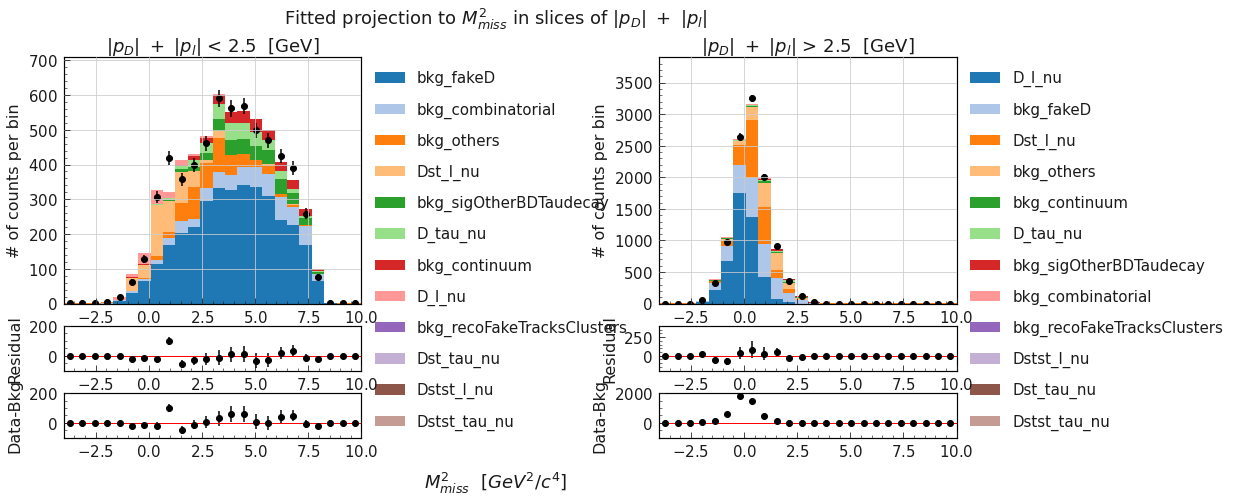

In [15]:
plot_projection_residual(direction='MM2',slices=True, plot_with='pltbar')

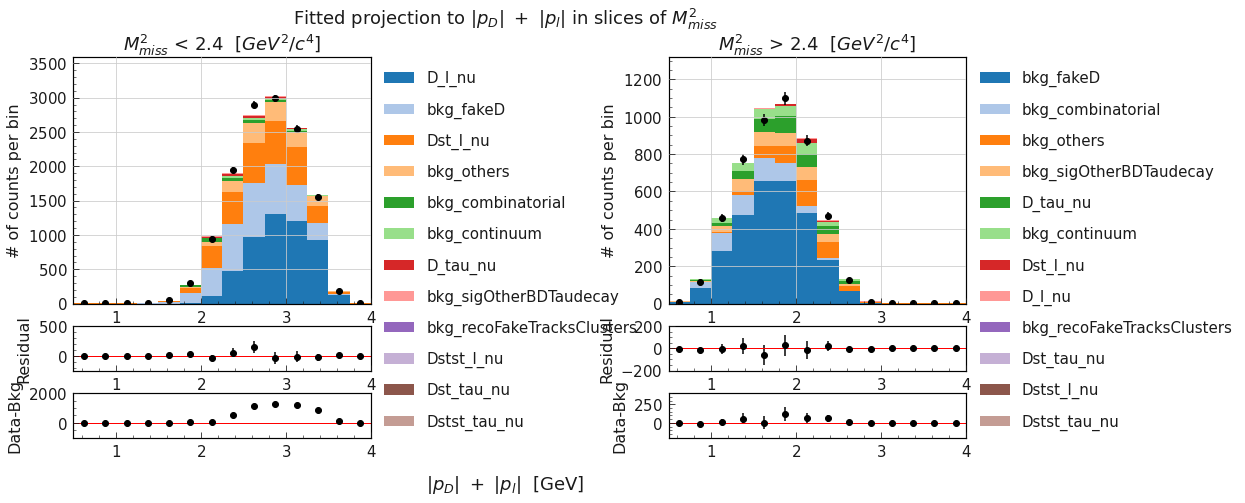

In [16]:
plot_projection_residual(direction='p_D_l',slices=True, plot_with='pltbar')

In [ ]:
# plotting version: residual_signals = data - all_temp + signal1 + signal2
def plot_projection_residual(direction='MM2', slices=False, plot_with='mplhep'):
    fitted_templates = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,0] for i in range(12)]
    fitted_templates_err = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,1] for i in range(12)]
    fitted_components_names = [model_1.spec['channels'][0]['samples'][i]['name'] for i in range(12)]
    
    def extend(x):
        return np.append(x, x[-1])
    
    def errorband(bins, template_sum, template_err, ax):
        fitted_sum = np.sum(template_sum, axis=0)
        fitted_err = np.sqrt(np.sum(np.array(template_err)**2, axis=0)) # assuming the correlations between each template are 0
        ax.fill_between(bins, extend(fitted_sum - fitted_err), extend(fitted_sum + fitted_err),
        step="post", color="black", alpha=0.3, linewidth=0, zorder=100,)
        
    def plot_with_hep(bins, templates_project, templates_project_err, data, signal_names, ax1, ax2):
        data_project = data.sum(axis=axis_to_be_summed_over)
        # plot the templates and data
        hep.histplot(templates_project, bin_edges, stack=True, histtype='fill', sort='yield_r', label=fitted_components_names, ax=ax1)
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        hep.histplot(data_project, bin_edges, histtype='errorbar', color='black', w2=data_project, ax=ax1)
        # plot the residual
        signal_index1 = fitted_components_names.index(signal_names[0])
        signal_index2 = fitted_components_names.index(signal_names[1])
        residual = data_project - np.sum(templates_project, axis=0)
        residual_signals = residual + templates_project[signal_index1] + templates_project[signal_index2]
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        residual_err_signals = np.sqrt(residual_err**2 - np.array(templates_project_err[signal_index1]) - np.array(templates_project_err[signal_index2]))
        hep.histplot(residual_signals, bin_edges, histtype='errorbar', color='black', yerr=residual_err_signals, ax=ax2)
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Data-Bkg',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)
        
    def plot_with_bar(bins, templates_project, templates_project_err, data, signal_names, ax1, ax2):        
        # calculate the arguments for plotting
        bin_width = bins[1]-bins[0]
        bin_centers = (bins[:-1] + bins[1:]) /2
        data_project = data.sum(axis=axis_to_be_summed_over)
        data_err = np.sqrt(data_project)
        
        # plot the templates
        # sort the components to plot in order of fitted templates_project size
        sorted_indices = sorted(range(12), key=lambda i: np.sum(templates_project[i]), reverse = True)
        bottom_hist = np.zeros(data.shape[1-axis_to_be_summed_over])
        for i in sorted_indices:
            binned_counts = templates_project[i]
            ax1.bar(x=bins[:-1], height=binned_counts, bottom=bottom_hist,
                    width=bin_width, align='edge', label=f"{fitted_components_names[i]}")
            bottom_hist = bottom_hist + binned_counts
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        
        # plot the data
        ax1.errorbar(x=bin_centers, y=data_project, yerr=data_err, fmt='ko')
        # plot the residual
        signal_index1 = fitted_components_names.index(signal_names[0])
        signal_index2 = fitted_components_names.index(signal_names[1])
        residual = data_project - np.sum(templates_project, axis=0)
        residual_signals = residual + templates_project[signal_index1] + templates_project[signal_index2]
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        residual_err_signals = np.sqrt(residual_err**2 - np.array(templates_project_err[signal_index1]) - np.array(templates_project_err[signal_index2]))
        ax2.errorbar(x=bin_centers, y=residual_signals, yerr=residual_err_signals, fmt='ko')
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Data-Bkg',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)
    
    if direction=='MM2':
        direction_label = '$M_{miss}^2$'
        direction_unit = '$[GeV^2/c^4]$'
        other_direction_label = '$|p_D|\ +\ |p_l|$'
        other_direction_unit = '[GeV]'
        slice1_signals = ['D_tau_nu', 'Dst_tau_nu']
        slice2_signals = ['D_l_nu', 'Dst_l_nu']
        slice_position = p_D_l_slice
        axis_to_be_summed_over = 1
        bin_edges = yedges
        first_slice_index = (p_D_l_slice_index[0]-1)
        second_slice_index = (p_D_l_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:,:first_slice_index]
        data_slice2 = counts[:,second_slice_index:]
        
    elif direction=='p_D_l':
        direction_label = '$|p_D|\ +\ |p_l|$'
        direction_unit = '[GeV]'
        other_direction_label = '$M_{miss}^2$'
        other_direction_unit = '$[GeV^2/c^4]$'
        slice1_signals = ['D_l_nu', 'Dst_l_nu']
        slice2_signals = ['D_tau_nu', 'Dst_tau_nu']
        slice_position = mm2_slice
        axis_to_be_summed_over = 0
        bin_edges = xedges
        first_slice_index = (mm2_slice_index[0]-1)
        second_slice_index = (mm2_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:first_slice_index,:]
        data_slice2 = counts[second_slice_index:,:]
        
    else:
        raise ValueError('Current version only supports projection to either MM2 or p_D_l')
    
    if not slices:
        fig = plt.figure(figsize=(6.4,6.4))
        gs = gridspec.GridSpec(3,1, height_ratios=[0.8,0.2])
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        #gs.update(hspace=0.3) 
        fitted_project = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_err = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        
        # plot the templates and data and templates_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project, fitted_project_err, counts, 'D_tau_nu', ax1, ax2)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project, fitted_project_err, counts, 'D_tau_nu', ax1, ax2)
        ax1.set_title(f'Fitting projection to {direction_label}')
        ax2.set_xlabel(direction_label)
    
    elif slices:
        fig = plt.figure(figsize=(16,7))
        spec = gridspec.GridSpec(5,2, figure=fig, wspace=1, hspace=0.5)
        ax1 = fig.add_subplot(spec[:-1, 0])
        ax2 = fig.add_subplot(spec[:-1, 1])
        ax3 = fig.add_subplot(spec[-1, 0])
        ax4 = fig.add_subplot(spec[-1, 1])
        #gs.update(hspace=0) 
        
        # plot the templates and data and template_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, slice1_signals, ax1, ax3)
            plot_with_hep(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, slice2_signals, ax2, ax4)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, slice1_signals, ax1, ax3)
            plot_with_bar(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, slice2_signals, ax2, ax4)
            
        ax1.set_title(f'{other_direction_label} < {slice_position}  {other_direction_unit}')
        ax2.set_title(f'{other_direction_label} > {slice_position}  {other_direction_unit}')
        fig.suptitle(f'Fitted projection to {direction_label} in slices of {other_direction_label}')
        fig.supxlabel(direction_label + '  ' + direction_unit)

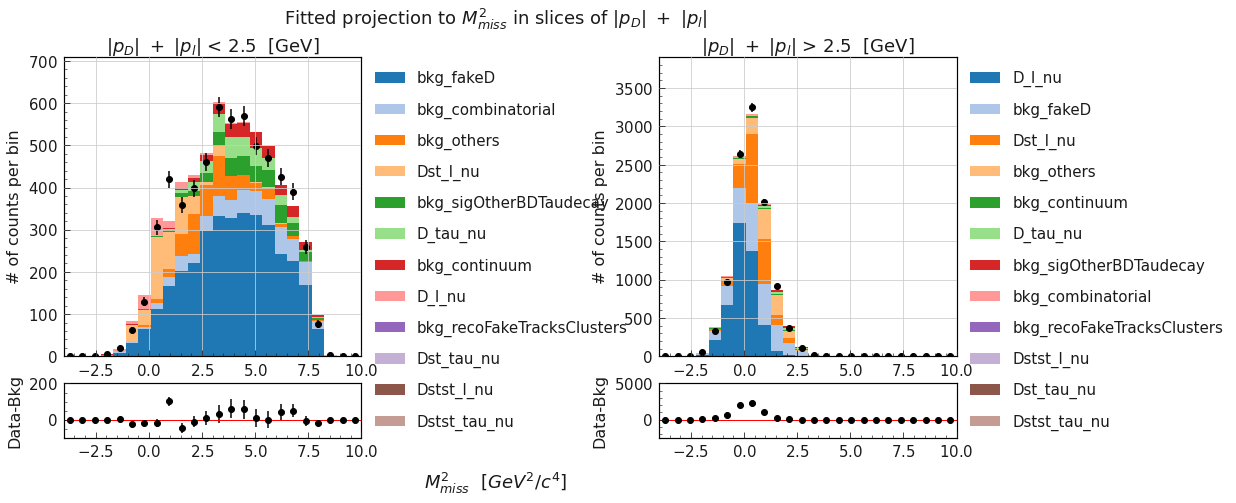

In [12]:
plot_projection_residual(direction='MM2',slices=True, plot_with='pltbar')

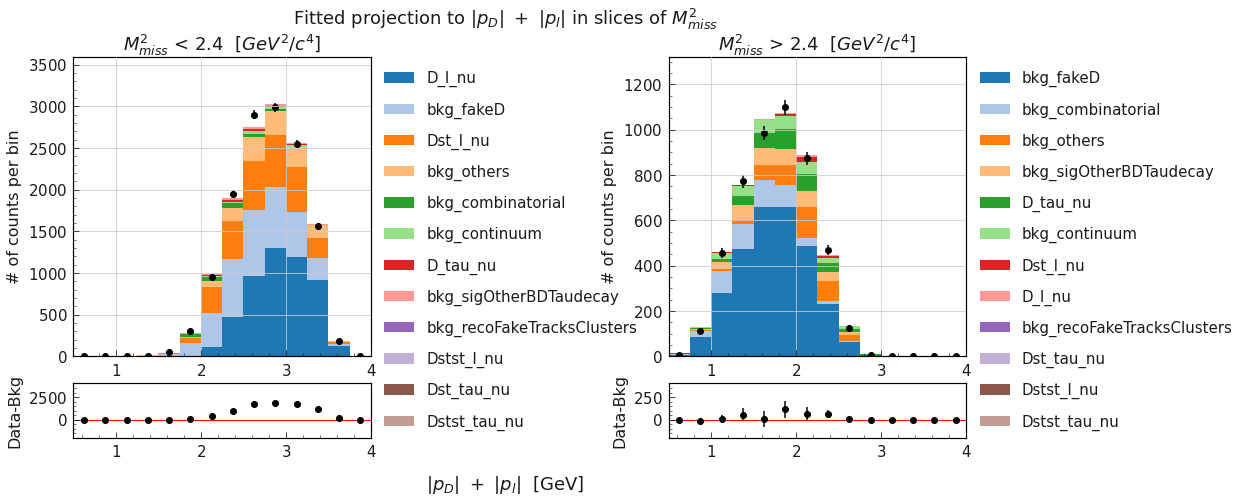

In [13]:
plot_projection_residual(direction='p_D_l',slices=True, plot_with='pltbar')

## Correlations

<ipython-input-37-0c26b0fd569d>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im0=axs.pcolormesh(X, Y,correlations)


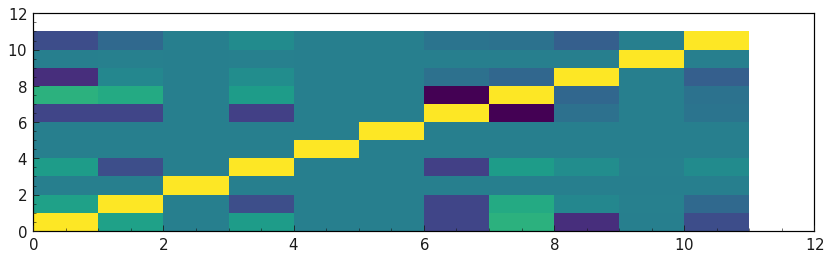

In [37]:
fig, axs = plt.subplots(figsize=(14,4))
a1=np.linspace(0, 11, 12)
X, Y = np.meshgrid(a1, a1)
im0=axs.pcolormesh(X, Y,correlations)

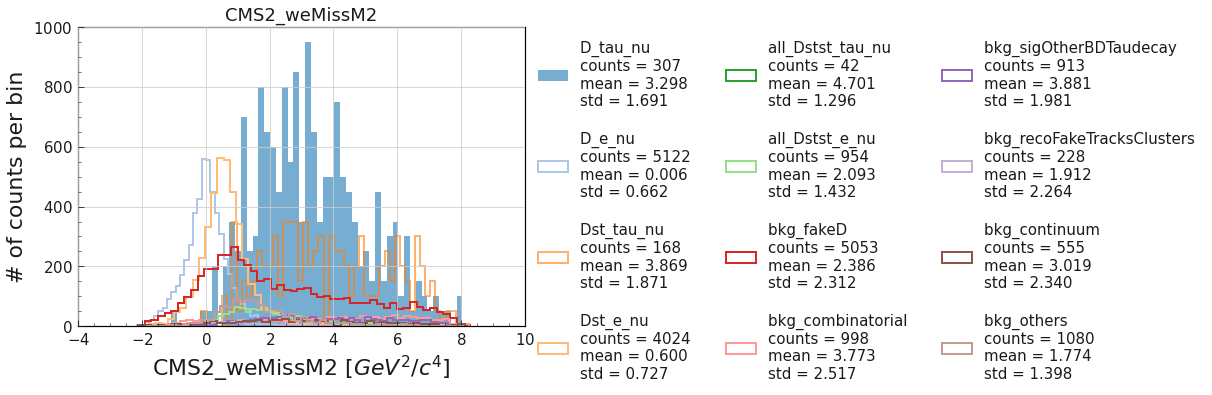

In [25]:
plot_components('MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26', 'B0_CMS2_weMissM2')
plt.xlabel("CMS2_weMissM2 $[GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('CMS2_weMissM2');
#plt.xlim(-10,10)